# Assignment 3 – Image Captioning  
# Phase 2 (Model 1): ViT-B/16 Encoder + GRU Decoder with Luong Attention

## Architecture Overview

| Component | Choice | Rationale |
|---|---|---|
| **Encoder** | ViT-B/16 (pretrained, ImageNet-21k) | Patch tokens give 196 spatially-aware embeddings; global self-attention captures long-range context — important for poorly-framed VizWiz images |
| **Attention** | Luong (multiplicative) over 196 patch tokens | Lightweight dot-product scoring; naturally operates on the sequence of patch tokens ViT produces |
| **Decoder** | 2-layer GRU | Lighter than LSTM (fewer gates), faster to train, competitive performance on captioning tasks |
| **Training** | Teacher forcing + cross-entropy, encoder fine-tuned (last 4 transformer blocks only) | Balances feature quality with training speed |

```
Image (224×224)
   │
   ▼
ViT-B/16  →  196 patch tokens (196 × 768)  →  Linear projection  →  (196 × 512)
                                                                           │
                                                              Luong Attention  ◄──── GRU hidden state
                                                                           │
                                                                   context vector (512)
                                                                           │
  word embedding (w_t, 512)  ──────────────────────────────────────────── ▼
                                                             [embed ∥ context]  →  2-layer GRU  →  FC  →  softmax  →  w_{t+1}


## 1. Imports and Configuration

In [ ]:
import os
import json
import pickle
import random
import math
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as tv_models

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB


## 2. Load Shared Artefacts from Phase 1

We load `shared_data.pkl` produced by Phase 1 notebook and reconstruct the `Vocabulary` object and dataset splits.

In [ ]:
# Defining Directory
DATA_DIR   = Path("/kaggle/input/datasets/sahaj25585973/vizwiz-images")
IMAGE_DIR  = DATA_DIR / "val"
SHARED_PKL = Path("/kaggle/input/datasets/sahaj25585973/processed-data/shared_data.pkl")
SAVE_DIR   = Path("/kaggle/working/vit_outputs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Loading shared data
with open(SHARED_PKL, "rb") as f:
    shared = pickle.load(f)

word2idx         = shared["vocab_word2idx"]
idx2word         = shared["vocab_idx2word"]
train_ids        = shared["train_ids"]
val_ids          = shared["val_ids"]
test_ids         = shared["test_ids"]
cleaned_captions = shared["cleaned_captions"]
id_to_file       = shared["id_to_file"]
MAX_CAPTION_LEN  = shared["max_caption_len"]

VOCAB_SIZE  = len(word2idx)
PAD_IDX     = word2idx["<pad>"]
START_IDX   = word2idx["<start>"]
END_IDX     = word2idx["<end>"]
UNK_IDX     = word2idx["<unk>"]

print(f"Vocab size       : {VOCAB_SIZE}")
print(f"Max caption len  : {MAX_CAPTION_LEN}")
print(f"Train / Val / Test: {len(train_ids)} / {len(val_ids)} / {len(test_ids)}")
print(f"PAD={PAD_IDX}  START={START_IDX}  END={END_IDX}  UNK={UNK_IDX}")

Vocab size       : 3519
Max caption len  : 22
Train / Val / Test: 6033 / 754 / 755
PAD=0  START=1  END=2  UNK=3


In [ ]:
# Reconstruct Vocabulary helper
class Vocabulary:
    def __init__(self, word2idx, idx2word):
        self.word2idx = word2idx
        self.idx2word = idx2word

    def encode(self, caption: str) -> list:
        tokens = caption.split()
        ids = [START_IDX]
        ids += [self.word2idx.get(t, UNK_IDX) for t in tokens]
        ids.append(END_IDX)
        return ids

    def decode(self, indices: list) -> str:
        words = []
        for idx in indices:
            w = self.idx2word.get(int(idx), "<unk>")
            if w == "<end>":
                break
            if w not in ("<pad>", "<start>"):
                words.append(w)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

vocab = Vocabulary(word2idx, idx2word)
print(f"Vocabulary reconstructed — {len(vocab)} tokens")

Vocabulary reconstructed — 3519 tokens


## 3. Dataset and DataLoader

We reuse the same `VizWizCaptionDataset` and collate functions from Phase 1, with the **ViT-specific transforms** (input size 224×224, same ImageNet normalisation).

In [ ]:
# Image transforms (ViT-B/16 expects 224×224, ImageNet normalisation)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
class VizWizCaptionDataset(Dataset):
    """
    mode='train' : flattened (image, caption) pairs — one row per caption.
    mode='eval'  : one row per image, returns all reference captions as strings.
    """
    def __init__(self, image_ids, captions_dict, vocab, id_to_file,
                 image_dir, transform=None, max_len=50, mode="train"):
        self.captions_dict = captions_dict
        self.vocab         = vocab
        self.id_to_file    = id_to_file
        self.image_dir     = Path(image_dir)
        self.transform     = transform
        self.max_len       = max_len
        self.mode          = mode

        if mode == "train":
            self.samples = [(img_id, cap)
                            for img_id in image_ids
                            for cap in captions_dict[img_id]]
        else:
            self.samples = [(img_id, captions_dict[img_id]) for img_id in image_ids]

    def __len__(self):
        return len(self.samples)

    def _load_image(self, img_id):
        path = self.image_dir / self.id_to_file[img_id]
        img  = Image.open(path).convert("RGB")
        return self.transform(img) if self.transform else transforms.ToTensor()(img)

    def __getitem__(self, index):
        if self.mode == "train":
            img_id, caption = self.samples[index]
            img     = self._load_image(img_id)
            encoded = self.vocab.encode(caption)
            length  = min(len(encoded), self.max_len)
            # Pad or truncate
            if len(encoded) < self.max_len:
                encoded += [PAD_IDX] * (self.max_len - len(encoded))
            else:
                encoded = encoded[:self.max_len - 1] + [END_IDX]
                length  = self.max_len
            return img, torch.tensor(encoded, dtype=torch.long), length
        else:
            img_id, captions_list = self.samples[index]
            img = self._load_image(img_id)
            return img, captions_list, img_id


def collate_train(batch):
    batch.sort(key=lambda x: x[2], reverse=True)
    images, captions, lengths = zip(*batch)
    return (torch.stack(images),
            torch.stack(captions),
            torch.tensor(lengths, dtype=torch.long))


def collate_eval(batch):
    images, all_captions, img_ids = zip(*batch)
    return torch.stack(images), list(all_captions), list(img_ids)


BATCH_SIZE  = 32
NUM_WORKERS = 0

train_dataset = VizWizCaptionDataset(train_ids, cleaned_captions, vocab, id_to_file, IMAGE_DIR,
                                     transform=train_transform, max_len=MAX_CAPTION_LEN, mode="train")

val_dataset = VizWizCaptionDataset(val_ids, cleaned_captions, vocab, id_to_file, IMAGE_DIR,
                                   transform=eval_transform, max_len=MAX_CAPTION_LEN, mode="eval")

test_dataset = VizWizCaptionDataset(test_ids, cleaned_captions, vocab, id_to_file, IMAGE_DIR,
                                    transform=eval_transform, max_len=MAX_CAPTION_LEN, mode="eval")

# Defining DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_train, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_eval,  pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_eval,  pin_memory=False)

print(f"Train samples : {len(train_dataset):,}  ({len(train_loader)} batches)")
print(f"Val   images  : {len(val_dataset):,}")
print(f"Test  images  : {len(test_dataset):,}")

# Sanity check
imgs, caps, lens = next(iter(train_loader))
print(f"\nBatch images  : {imgs.shape}")
print(f"Batch captions: {caps.shape}")
print(f"Sample decoded: '{vocab.decode(caps[0].tolist())}'")

Train samples : 26,436  (827 batches)
Val   images  : 754
Test  images  : 755

Batch images  : torch.Size([32, 3, 224, 224])
Batch captions: torch.Size([32, 22])
Sample decoded: 'a video is showing a chemistry sample problem with a girl at the foot of the page and her <unk>'


## 4. Model Architecture

### 4.1 ViT-B/16 Encoder

In [ ]:
class ViTEncoder(nn.Module):
    """
    ViT-B/16 patch-token encoder.

    Returns the 196 patch tokens (the CLS token is discarded).
    Patch tokens carry spatially-grounded information because each of the 16×16
    patches corresponds to a fixed region of the input image.

    Fine-tuning strategy
    --------------------
    All parameters are frozen initially. Only the last `n_unfreeze` transformer
    encoder blocks are unfrozen for fine-tuning (plus the projection layer).
    This keeps training memory low while still adapting the high-level features.

    Output
    ------
    patch_feats : (B, 196, embed_dim)
    """
    def __init__(self, embed_dim: int = 512, n_unfreeze: int = 4):
        super().__init__()
        # Load pretrained ViT-B/16
        vit = tv_models.vit_b_16(weights=tv_models.ViT_B_16_Weights.IMAGENET1K_V1)

        # Keep everything except the classification head
        self.patch_embedding = vit.conv_proj          # (B,3,224,224) → (B,768,14,14)
        self.class_token      = vit.class_token        # (1,1,768)
        self.pos_embedding    = vit.encoder.pos_embedding  # (1,197,768)
        self.encoder_blocks   = vit.encoder.layers     # ModuleList of 12 blocks
        self.ln               = vit.encoder.ln         # final layer norm

        # Projection from ViT hidden dim (768) to decoder embed_dim
        self.projection = nn.Sequential(
            nn.Linear(768, embed_dim),
            nn.ReLU(),
        )

        # Freeze all ViT parameters
        for p in [self.patch_embedding, self.class_token,
                  self.pos_embedding, self.encoder_blocks, self.ln]:
            if isinstance(p, nn.Parameter):
                p.requires_grad_(False)
            else:
                for param in (p.parameters() if hasattr(p, 'parameters') else []):
                    param.requires_grad_(False)

        # Unfreeze the last n_unfreeze blocks
        num_blocks = len(self.encoder_blocks)
        for i in range(num_blocks - n_unfreeze, num_blocks):
            for param in self.encoder_blocks[i].parameters():
                param.requires_grad_(True)
        # Always train the final layer norm and projection
        for param in self.ln.parameters():
            param.requires_grad_(True)

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"[ViTEncoder] trainable params: {trainable:,} / {total:,} "
              f"({100*trainable/total:.1f}%)")

    def forward(self, x):
        """
        x : (B, 3, 224, 224)
        Returns patch_feats : (B, 196, embed_dim)
        """
        B = x.size(0)

        # 1. Patchify
        x = self.patch_embedding(x)          # (B, 768, 14, 14)
        x = x.flatten(2).transpose(1, 2)     # (B, 196, 768)

        # 2. Prepend CLS token
        cls = self.class_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)

        # 3. Add positional embedding
        x = x + self.pos_embedding

        # 4. Transformer encoder blocks
        for block in self.encoder_blocks:
            x = block(x)
        x = self.ln(x)

        # 5. Drop CLS token — keep only patch tokens
        patch_tokens = x[:, 1:, :]

        # 6. Project to decoder dimension
        patch_feats = self.projection(patch_tokens) # (B, 196, embed_dim)
        return patch_feats

### 4.2 Luong Attention

In [ ]:
class LuongAttention(nn.Module):
    def __init__(self, encoder_dim: int, decoder_dim: int):
        super().__init__()
        self.W_a = nn.Linear(decoder_dim, encoder_dim, bias=False)

    def forward(self, hidden, encoder_out):
        """
        hidden      : (B, decoder_dim)
        encoder_out : (B, 196, encoder_dim)
        """
        # Project decoder hidden state → encoder space: (B, encoder_dim)
        query = self.W_a(hidden)               # (B, encoder_dim)

        # Dot product with every patch: (B, 196)
        scores = torch.bmm(
            encoder_out,                       # (B, 196, encoder_dim)
            query.unsqueeze(2)                 # (B, encoder_dim, 1)
        ).squeeze(2)                           # (B, 196)

        attn_wts = F.softmax(scores, dim=1)    # (B, 196)

        # Weighted sum of patch features
        context = torch.bmm(
            attn_wts.unsqueeze(1),             # (B, 1, 196)
            encoder_out                        # (B, 196, encoder_dim)
        ).squeeze(1)                           # (B, encoder_dim)

        return context, attn_wts

### 4.3 GRU Decoder

In [ ]:
class GRUDecoder(nn.Module):
    """
    2-layer GRU decoder with Luong attention over ViT patch tokens.

    Parameters
    ----------
    vocab_size   : number of tokens
    embed_dim    : word embedding + encoder projection dimension
    decoder_dim  : GRU hidden size
    encoder_dim  : must match ViTEncoder embed_dim
    num_layers   : GRU depth
    dropout      : dropout probability (applied between GRU layers)
    """
    def __init__(self, vocab_size, embed_dim=512, decoder_dim=512,
                 encoder_dim=512, num_layers=2, dropout=0.5):
        super().__init__()
        self.embed_dim   = embed_dim
        self.decoder_dim = decoder_dim
        self.num_layers  = num_layers

        # Word embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Attention
        self.attention = LuongAttention(encoder_dim, decoder_dim)

        # GRU input: [embed ∥ context] → (embed_dim + encoder_dim)
        self.gru = nn.GRU(
            input_size  = embed_dim + encoder_dim,
            hidden_size = decoder_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )

        # Initialise GRU hidden state from mean-pooled patch features
        self.init_h = nn.Linear(encoder_dim, decoder_dim)

        # Output projection
        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(decoder_dim, vocab_size)

    def _init_hidden(self, encoder_out):
        """
        Initialise all GRU layers from the mean of the patch features.
        encoder_out : (B, 196, encoder_dim)
        Returns     : (num_layers, B, decoder_dim)
        """
        mean_feat = encoder_out.mean(dim=1)          # (B, encoder_dim)
        h0 = torch.tanh(self.init_h(mean_feat))      # (B, decoder_dim)
        return h0.unsqueeze(0).repeat(self.num_layers, 1, 1)

    def forward(self, encoder_out, captions, lengths):
        B        = encoder_out.size(0)
        max_t    = captions.size(1) - 1   # we predict t+1 from t (drop last)

        # Embed all tokens except the last (<end> is never an input)
        embeds = self.embedding(captions[:, :-1])     # (B, max_t, embed_dim)

        hidden = self._init_hidden(encoder_out)

        all_logits  = []
        all_attns   = []

        for t in range(max_t):
            # Use top-layer hidden state for attention
            h_top = hidden[-1]                         # (B, decoder_dim)

            context, attn_wts = self.attention(h_top, encoder_out)

            gru_in = torch.cat([embeds[:, t, :], context], dim=1)  # (B, embed+enc)
            gru_in = gru_in.unsqueeze(1)                            # (B, 1, embed+enc)

            out, hidden = self.gru(gru_in, hidden)    # out: (B, 1, dec_dim)

            logits = self.fc_out(self.dropout(out.squeeze(1)))  # (B, vocab_size)
            all_logits.append(logits)
            all_attns.append(attn_wts)

        logits       = torch.stack(all_logits, dim=1)  # (B, max_t, vocab_size)
        attn_weights = torch.stack(all_attns,  dim=1)  # (B, max_t, 196)
        return logits, attn_weights

    @torch.no_grad()
    def greedy_decode(self, encoder_out, max_len=50):
        hidden   = self._init_hidden(encoder_out)          # (layers, 1, dec_dim)
        word_idx = torch.tensor([[START_IDX]], device=encoder_out.device)
        result   = []

        for _ in range(max_len):
            h_top   = hidden[-1]                           # (1, dec_dim)
            context, _ = self.attention(h_top, encoder_out)
            embed   = self.embedding(word_idx)             # (1, 1, embed_dim)
            gru_in  = torch.cat([embed.squeeze(1), context], dim=1).unsqueeze(1)
            out, hidden = self.gru(gru_in, hidden)
            logits  = self.fc_out(out.squeeze(1))          # (1, vocab_size)
            word_idx = logits.argmax(dim=1, keepdim=True)  # (1, 1)
            token    = word_idx.item()
            if token == END_IDX:
                break
            result.append(token)

        return result

    @torch.no_grad()
    def beam_search(self, encoder_out, beam_size=5, max_len=50):
        device = encoder_out.device
        hidden = self._init_hidden(encoder_out)   # (layers, 1, dec_dim)

        # Each beam: (score, token_sequence, hidden_state)
        beams = [(0.0, [START_IDX], hidden)]
        completed = []

        for _ in range(max_len):
            candidates = []
            for score, seq, hid in beams:
                if seq[-1] == END_IDX:
                    completed.append((score, seq))
                    continue
                word_idx = torch.tensor([[seq[-1]]], device=device)
                h_top    = hid[-1]
                context, _ = self.attention(h_top, encoder_out)
                embed    = self.embedding(word_idx).squeeze(1)
                gru_in   = torch.cat([embed, context], dim=1).unsqueeze(1)
                out, new_hid = self.gru(gru_in, hid)
                log_probs = F.log_softmax(self.fc_out(out.squeeze(1)), dim=1)
                top_probs, top_idxs = log_probs.topk(beam_size)
                for prob, idx in zip(top_probs[0], top_idxs[0]):
                    candidates.append(
                        (score + prob.item(), seq + [idx.item()], new_hid)
                    )
            if not candidates:
                break
            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_size]

        # Collect any unfinished beams
        for score, seq, _ in beams:
            completed.append((score, seq))

        best = sorted(completed, key=lambda x: x[0], reverse=True)[0][1]
        # Strip <start> and <end>
        return [t for t in best if t not in (START_IDX, END_IDX, PAD_IDX)]

### 4.4 Full Model Wrapper

In [ ]:
class VitGRUCaptioner(nn.Module):
    """End-to-end ViT-B/16 encoder + GRU decoder with Luong attention."""

    def __init__(self, vocab_size, embed_dim=512, decoder_dim=512,
                 num_layers=2, dropout=0.5, n_unfreeze=4):
        super().__init__()
        self.encoder = ViTEncoder(embed_dim=embed_dim, n_unfreeze=n_unfreeze)
        self.decoder = GRUDecoder(
            vocab_size   = vocab_size,
            embed_dim    = embed_dim,
            decoder_dim  = decoder_dim,
            encoder_dim  = embed_dim,
            num_layers   = num_layers,
            dropout      = dropout,
        )

    def forward(self, images, captions, lengths):
        encoder_out = self.encoder(images)                # (B, 196, embed_dim)
        logits, attn = self.decoder(encoder_out, captions, lengths)
        return logits, attn

    @torch.no_grad()
    def generate(self, image, method="greedy", beam_size=5, max_len=50):
        """
        Generate a caption for a single image tensor (1, 3, 224, 224).
        method : 'greedy' or 'beam'
        Returns decoded caption string.
        """
        self.eval()
        encoder_out = self.encoder(image)                 # (1, 196, embed_dim)
        if method == "beam":
            token_ids = self.decoder.beam_search(encoder_out, beam_size, max_len)
        else:
            token_ids = self.decoder.greedy_decode(encoder_out, max_len)
        return vocab.decode(token_ids)


# Instantiate and inspect
model = VitGRUCaptioner(
    vocab_size   = VOCAB_SIZE,
    embed_dim    = 512,
    decoder_dim  = 512,
    num_layers   = 2,
    dropout      = 0.5,
    n_unfreeze   = 4,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 225MB/s]  


[ViTEncoder] trainable params: 28,746,752 / 86,192,384 (33.4%)

Total parameters     : 94,262,463
Trainable parameters : 36,816,831 (39.1%)


## 5. Training Setup

In [ ]:
# Hyperparameters
NUM_EPOCHS      = 20
GRAD_CLIP       = 5.0
PATIENCE        = 5     # early stopping patience (epochs without BLEU-4 improvement)

# Two parameter groups: encoder (fine-tuned blocks) gets a lower LR
optimizer = optim.AdamW([
    {"params": model.encoder.parameters(), "lr": 1e-5, "weight_decay": 1e-4},
    {"params": model.decoder.parameters(), "lr": 4e-4, "weight_decay": 1e-4},
])

# Cosine annealing scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# Cross-entropy loss — ignore PAD tokens
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print("Optimizer  : AdamW (two parameter groups)")
print("Scheduler  : CosineAnnealingLR")
print("Loss       : CrossEntropyLoss (ignore_index=PAD)")
print(f"Epochs     : {NUM_EPOCHS}  |  Grad clip: {GRAD_CLIP}  |  Patience: {PATIENCE}")

Optimizer  : AdamW (two parameter groups)
Scheduler  : CosineAnnealingLR
Loss       : CrossEntropyLoss (ignore_index=PAD)
Epochs     : 20  |  Grad clip: 5.0  |  Patience: 5


In [ ]:
# BLEU evaluation helper method
def evaluate_bleu(model, loader, device, method="greedy", max_len=50):
    """
    Run the model over the eval loader and return BLEU-1..4.
    loader yields: (images, list_of_ref_caption_lists, img_ids)
    """
    model.eval()
    all_refs = []   # list of list-of-tokenised-references per image
    all_hyps = []   # list of tokenised hypotheses

    with torch.no_grad():
        for images, ref_caps_batch, _ in tqdm(loader, desc="BLEU eval", leave=False):
            images = images.to(device)
            encoder_out = model.encoder(images)   # (B, 196, embed_dim)

            for i in range(images.size(0)):
                enc_single = encoder_out[i].unsqueeze(0)
                if method == "beam":
                    token_ids = model.decoder.beam_search(enc_single, max_len=max_len)
                else:
                    token_ids = model.decoder.greedy_decode(enc_single, max_len=max_len)

                hypothesis = vocab.decode(token_ids).split()
                references = [cap.split() for cap in ref_caps_batch[i]]

                all_hyps.append(hypothesis)
                all_refs.append(references)

    sf = SmoothingFunction().method1
    bleu1 = corpus_bleu(all_refs, all_hyps, weights=(1, 0, 0, 0))
    bleu2 = corpus_bleu(all_refs, all_hyps, weights=(0.5, 0.5, 0, 0))
    bleu3 = corpus_bleu(all_refs, all_hyps, weights=(1/3, 1/3, 1/3, 0))
    bleu4 = corpus_bleu(all_refs, all_hyps, weights=(0.25, 0.25, 0.25, 0.25))
    return {"bleu1": bleu1, "bleu2": bleu2, "bleu3": bleu3, "bleu4": bleu4}

## 6. Training Loop

In [ ]:
history = {
    "train_loss": [],
    "val_bleu1":  [], "val_bleu2": [], "val_bleu3": [], "val_bleu4": [],
}

best_bleu4      = 0.0
patience_counter = 0
BEST_CKPT = SAVE_DIR / "vit_gru_best.pth"

for epoch in range(1, NUM_EPOCHS + 1):

    # Training
    model.train()
    epoch_loss = 0.0
    n_batches  = 0

    for images, captions, lengths in tqdm(train_loader,
                                          desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]",
                                          leave=False):
        images, captions = images.to(DEVICE), captions.to(DEVICE)

        logits, _ = model(images, captions, lengths)   # (B, max_t-1, vocab_size)

        B, T, V = logits.shape
        loss = criterion(
            logits.reshape(B * T, V),
            captions[:, 1:B * T // B + 1].reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    avg_loss = epoch_loss / n_batches
    scheduler.step()

    # Validation BLEU
    val_scores = evaluate_bleu(model, val_loader, DEVICE, method="greedy")

    history["train_loss"].append(avg_loss)
    for k in ("bleu1", "bleu2", "bleu3", "bleu4"):
        history[f"val_{k}"].append(val_scores[k])

    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | "
          f"BLEU-1: {val_scores['bleu1']:.4f} | "
          f"BLEU-2: {val_scores['bleu2']:.4f} | "
          f"BLEU-3: {val_scores['bleu3']:.4f} | "
          f"BLEU-4: {val_scores['bleu4']:.4f}")

    # Checkpoint + early stopping
    if val_scores["bleu4"] > best_bleu4:
        best_bleu4 = val_scores["bleu4"]
        patience_counter = 0
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "bleu4"      : best_bleu4,
            "history"    : history,
        }, BEST_CKPT)
        print(f"  ✅ New best BLEU-4: {best_bleu4:.4f} — checkpoint saved")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

print(f"\nTraining complete. Best BLEU-4: {best_bleu4:.4f}")

Epoch 01 | Loss: 4.4460 | BLEU-1: 0.4056 | BLEU-2: 0.2404 | BLEU-3: 0.1387 | BLEU-4: 0.0744
  ✅ New best BLEU-4: 0.0744 — checkpoint saved


Epoch 02 | Loss: 3.7439 | BLEU-1: 0.3933 | BLEU-2: 0.2496 | BLEU-3: 0.1522 | BLEU-4: 0.0901
  ✅ New best BLEU-4: 0.0901 — checkpoint saved


Epoch 03 | Loss: 3.4801 | BLEU-1: 0.5262 | BLEU-2: 0.3458 | BLEU-3: 0.2190 | BLEU-4: 0.1318
  ✅ New best BLEU-4: 0.1318 — checkpoint saved


Epoch 04 | Loss: 3.2996 | BLEU-1: 0.4618 | BLEU-2: 0.3011 | BLEU-3: 0.1900 | BLEU-4: 0.1141
  No improvement (1/5)


Epoch 05 | Loss: 3.1632 | BLEU-1: 0.4504 | BLEU-2: 0.2915 | BLEU-3: 0.1844 | BLEU-4: 0.1136
  No improvement (2/5)


...

Epoch 14 | Loss: 2.5014 | BLEU-1: 0.5541 | BLEU-2: 0.3610 | BLEU-3: 0.2267 | BLEU-4: 0.1394
  No improvement (1/5)


Epoch 15 | Loss: 2.4621 | BLEU-1: 0.5515 | BLEU-2: 0.3593 | BLEU-3: 0.2277 | BLEU-4: 0.1418
  No improvement (2/5)


Epoch 16 | Loss: 2.4326 | BLEU-1: 0.5550 | BLEU-2: 0.3649 | BLEU-3: 0.2315 | BLEU-4: 0.1437
  No improvement (3/5)


Epoch 17 | Loss: 2.4068 | BLEU-1: 0.5604 | BLEU-2: 0.3649 | BLEU-3: 0.2301 | BLEU-4: 0.1433
  No improvement (4/5)


Epoch 18 | Loss: 2.3917 | BLEU-1: 0.5581 | BLEU-2: 0.3641 | BLEU-3: 0.2305 | BLEU-4: 0.1421
  No improvement (5/5)
Early stopping triggered.

Training complete. Best BLEU-4: 0.1477


## 7. Training Curves

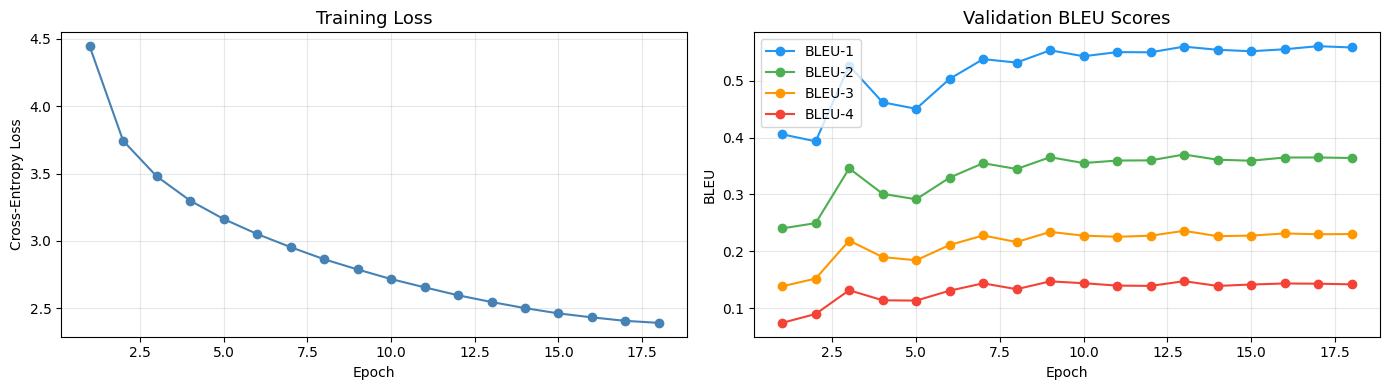

In [ ]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_ran, history["train_loss"], marker="o", color="steelblue")
axes[0].set_title("Training Loss", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(True, alpha=0.3)

for key, label, color in [
    ("val_bleu1", "BLEU-1", "#2196F3"),
    ("val_bleu2", "BLEU-2", "#4CAF50"),
    ("val_bleu3", "BLEU-3", "#FF9800"),
    ("val_bleu4", "BLEU-4", "#F44336"),
]:
    axes[1].plot(epochs_ran, history[key], marker="o", label=label, color=color)

axes[1].set_title("Validation BLEU Scores", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("BLEU")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / "training_curves.png", dpi=120)
plt.show()

## 8. Final Evaluation on Test Set

Load the best checkpoint and evaluate with both greedy and beam search decoding.

In [ ]:
# Load best checkpoint
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val BLEU-4: {ckpt['bleu4']:.4f})")

# Greedy decoding
print("\n── Greedy decoding ──")
greedy_scores = evaluate_bleu(model, test_loader, DEVICE, method="greedy")
for k, v in greedy_scores.items():
    print(f"  {k.upper()}: {v:.4f}")

# Beam search (beam=5)
print("\n── Beam search (k=5) ──")
beam_scores = evaluate_bleu(model, test_loader, DEVICE, method="beam")
for k, v in beam_scores.items():
    print(f"  {k.upper()}: {v:.4f}")

# Save results
results = {
    "architecture" : "ViT-B/16 Encoder + 2-layer GRU Decoder (Luong Attention)",
    "best_val_bleu4": ckpt["bleu4"],
    "test_greedy"  : greedy_scores,
    "test_beam5"   : beam_scores,
    "hyperparameters": {
        "embed_dim"  : 512,
        "decoder_dim": 512,
        "num_layers" : 2,
        "dropout"    : 0.5,
        "n_unfreeze" : 4,
        "batch_size" : BATCH_SIZE,
        "num_epochs" : ckpt["epoch"],
        "optimizer"  : "AdamW",
        "scheduler"  : "CosineAnnealingLR",
    }
}

with open(SAVE_DIR / "vit_gru_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✅ Results saved to vit_gru_results.json")

Loaded best checkpoint from epoch 13 (val BLEU-4: 0.1477)

── Greedy decoding ──


  BLEU1: 0.5578
  BLEU2: 0.3685
  BLEU3: 0.2352
  BLEU4: 0.1448

── Beam search (k=5) ──


  BLEU1: 0.5843
  BLEU2: 0.3939
  BLEU3: 0.2634
  BLEU4: 0.1724

✅ Results saved to vit_gru_results.json


## 9. Qualitative Analysis — Visual Inspection

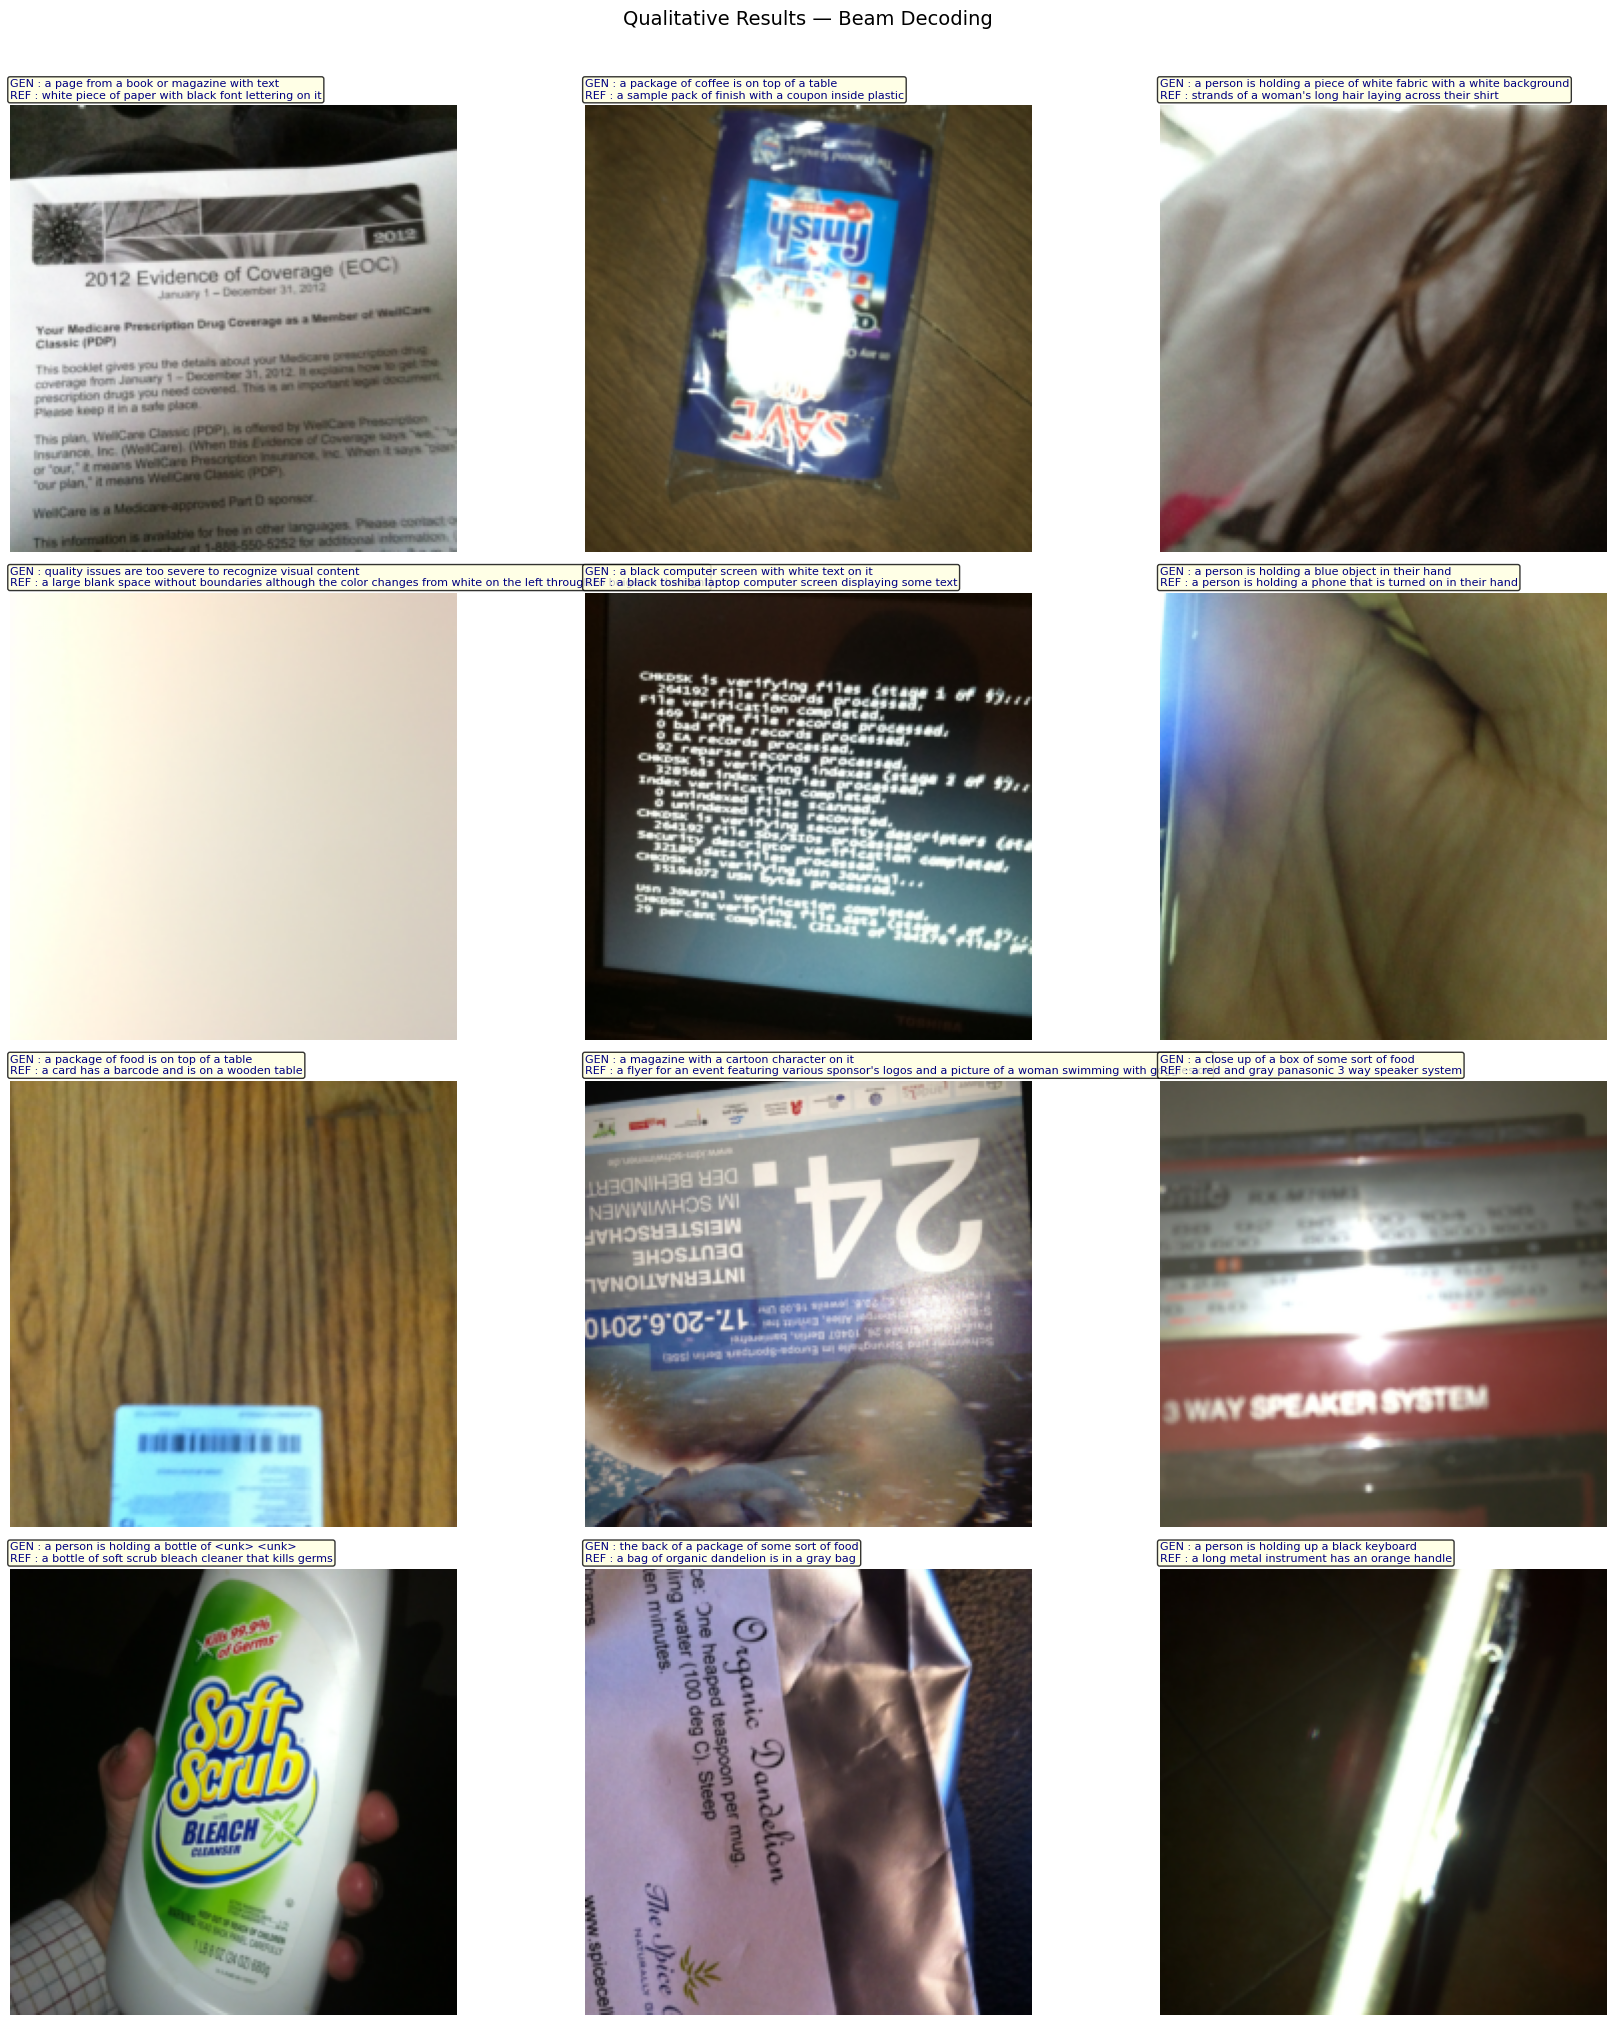

In [ ]:
def show_sample_captions(model, dataset, n=12, method="beam", seed=0):
    """
    Display n random images from the dataset with generated vs reference captions.
    """
    random.seed(seed)
    indices = random.sample(range(len(dataset)), n)
    model.eval()

    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))

    inv_norm = transforms.Normalize(
        mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
        std=[1/s for s in IMAGENET_STD]
    )

    for ax, idx in zip(axes.flat, indices):
        img_tensor, ref_caps, img_id = dataset[idx]

        # Generate caption
        generated = model.generate(img_tensor.unsqueeze(0).to(DEVICE),method=method)

        # Display image (un-normalise for visualisation)
        disp = inv_norm(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(disp)
        ax.axis("off")

        # Title: generated + first reference
        title = f"GEN : {generated}\nREF : {ref_caps[0]}"
        ax.set_title(title, fontsize=8, loc="left", wrap=True,
                     color="navy",
                     bbox=dict(boxstyle="round,pad=0.2", fc="lightyellow", alpha=0.8))

    # Hide any unused axes
    for ax in axes.flat[n:]:
        ax.axis("off")

    plt.suptitle(f"Qualitative Results — {method.capitalize()} Decoding", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"qualitative_{method}.png", dpi=100, bbox_inches="tight")
    plt.show()


show_sample_captions(model, test_dataset, n=12, method="beam")

## 10. Additional Metrics

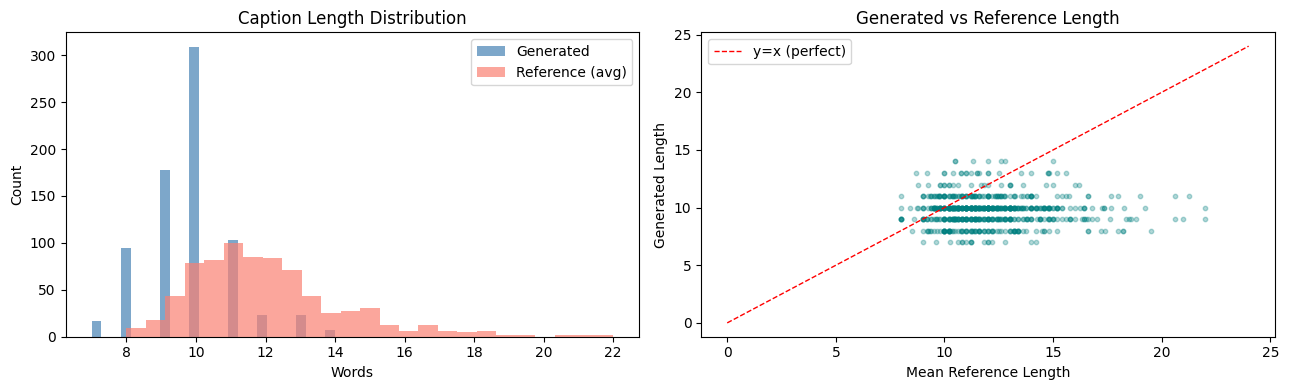

Mean generated caption length : 9.8 words
Mean reference caption length : 12.0 words


In [ ]:
# Caption length analysis
model.eval()
gen_lengths  = []
ref_lengths  = []
hypotheses   = []
references   = []

with torch.no_grad():
    for images, ref_caps_batch, _ in tqdm(test_loader, desc="Collecting captions"):
        images = images.to(DEVICE)
        encoder_out = model.encoder(images)
        for i in range(images.size(0)):
            enc = encoder_out[i].unsqueeze(0)
            token_ids = model.decoder.beam_search(enc)
            hyp = vocab.decode(token_ids)
            hypotheses.append(hyp)
            references.append(ref_caps_batch[i])
            gen_lengths.append(len(hyp.split()))
            ref_lengths.append(np.mean([len(c.split()) for c in ref_caps_batch[i]]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(gen_lengths, bins=25, alpha=0.7, color="steelblue",  label="Generated")
axes[0].hist(ref_lengths, bins=25, alpha=0.7, color="salmon",     label="Reference (avg)")
axes[0].set_title("Caption Length Distribution", fontsize=12)
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].scatter(ref_lengths, gen_lengths, alpha=0.3, s=10, color="teal")
lim = max(max(ref_lengths), max(gen_lengths)) + 2
axes[1].plot([0, lim], [0, lim], "r--", lw=1, label="y=x (perfect)")
axes[1].set_title("Generated vs Reference Length", fontsize=12)
axes[1].set_xlabel("Mean Reference Length")
axes[1].set_ylabel("Generated Length")
axes[1].legend()

plt.tight_layout()
plt.savefig(SAVE_DIR / "length_analysis.png", dpi=120)
plt.show()

print(f"Mean generated caption length : {np.mean(gen_lengths):.1f} words")
print(f"Mean reference caption length : {np.mean(ref_lengths):.1f} words")

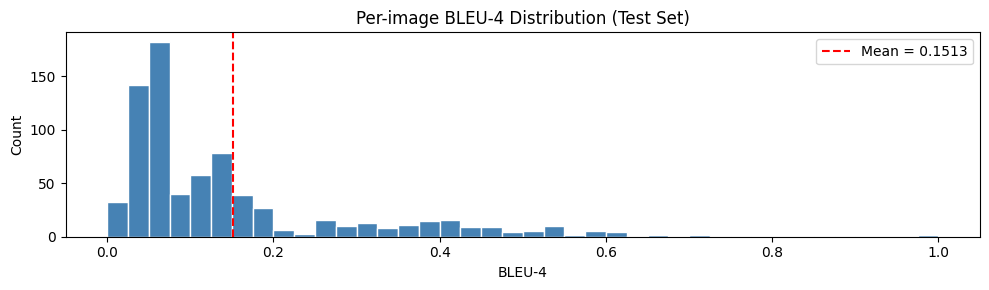


Top 3 captions (highest BLEU-4):
  [1.0000] GEN: a black computer screen with white text on it
           REF: a computer screen displaying black and white text
  [1.0000] GEN: a computer screen is displaying a window with a message
           REF: a computer screen with an antenna ear behind it and a speaker on the side of it
  [0.8801] GEN: a can of food is on top of a table
           REF: the nutrition facts panel of a food or drink canister

Bottom 3 captions (lowest BLEU-4):
  [0.0000] GEN: quality issues are too severe to recognize visual content
           REF: grainy dark gray surface with nothing on it
  [0.0000] GEN: quality issues are too severe to recognize visual content
           REF: a bright blinding light is obstructing all view
  [0.0000] GEN: quality issues are too severe to recognize visual content
           REF: a blank screen that is nothing but black


In [ ]:
# Per-image BLEU-4 distribution
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

sf = SmoothingFunction().method1
per_image_bleu4 = []

for hyp, refs in zip(hypotheses, references):
    score = sentence_bleu(
        [r.split() for r in refs],
        hyp.split(),
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=sf
    )
    per_image_bleu4.append(score)

plt.figure(figsize=(10, 3))
plt.hist(per_image_bleu4, bins=40, color="steelblue", edgecolor="white")
plt.axvline(np.mean(per_image_bleu4), color="red", linestyle="--",
            label=f"Mean = {np.mean(per_image_bleu4):.4f}")
plt.title("Per-image BLEU-4 Distribution (Test Set)", fontsize=12)
plt.xlabel("BLEU-4")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / "per_image_bleu4.png", dpi=120)
plt.show()

# Find best and worst examples
sorted_idx = np.argsort(per_image_bleu4)
print("\nTop 3 captions (highest BLEU-4):")
for idx in sorted_idx[-3:][::-1]:
    print(f"  [{per_image_bleu4[idx]:.4f}] GEN: {hypotheses[idx]}")
    print(f"           REF: {references[idx][0]}")

print("\nBottom 3 captions (lowest BLEU-4):")
for idx in sorted_idx[:3]:
    print(f"  [{per_image_bleu4[idx]:.4f}] GEN: {hypotheses[idx]}")
    print(f"           REF: {references[idx][0]}")